# HHBANK - 2 COUNTRY GITHUB VERSION 

In [7]:
# PACKAGES AND PATHS 
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np


from pathlib import Path
import numpy as np
from sequence_jacobian import grids

try:
    BASE_DIR_D = Path(__file__).resolve().parent
except NameError:
    BASE_DIR_D = Path.cwd()


DATA_DIR_D = BASE_DIR_D / "Discretisation" / "Outputs"


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# CALIBRATION
# ═══════════════════════════════════════════════════════════════════════
calibration_start = {

    # ── Preferences ──────────────────────────────────────────────────────
    #                              D               F
    'frisch_D':     0.50,    'frisch_F':     0.50,    # Frisch elasticity of labour supply 
    'eis_D':        0.5,    'eis_F':        0.5,    # Elasticity of intertemporal substitution

    # ── Rates & Asset Prices ─────────────────────────────────────────────
    'rdep_D':       0.000, 'rdep_F':       0.000, # Real deposit rate (initial guess; endogenous in transition)
    'q_b_D':        0.83,   'q_b_F':        0.83,   # Bond price (initial guess)
    'Q_D':          1.0,    'Q_F':          1.0,    # Tobin's q

    # ── Production ───────────────────────────────────────────────────────
    'alpha_D':      0.35,   'alpha_F':      0.35,   # Capital share
    'delta_D':      0.025, 'delta_F':      0.025,   # Quarterly depreciation rate
    'ksi_D':        0.50,    'ksi_F':        0.50,    # Capital adjustment cost curvature

    # ── Long-term bonds ───────────────────────────────────────────────────
    'delta_b_D':   0.10,   'delta_b_F':    0.10,

    # ── Aggregate Targets (SS) ───────────────────────────────────────────
    'Y_D':          1.00,   'Y_F':          1.00,   # Output
    'Y_ss_D':       1.0,    'Y_ss_F':       1.0,    # SS output anchor (government_default debt-gap)
    'N_D':          1.00,   'N_F':          1.00,   # Labour
    'w_D':          0.65,   'w_F':          0.65,   # Real wage

    # ── Financial Intermediaries (Gertler-Karadi) ─────────────────────────
    'f_D':          0.12,   'f_F':          0.12,   # Exit probability
    'lambda_gk_D':  0.2,    'lambda_gk_F':  0.2,    # Divertability fraction (IC constraint & P1 Bellman)
    'beta_inter_D': 0.9975155088,  'beta_inter_F': 0.9975155088,  # Banker discount factors → 1.7%/yr govt bond yield
    'Delta_bD_D':   0.2,    'Delta_bF_F':   0.2,    # Domestic bonds (preferred — better collateral)
    'Delta_bF_D':   0.4,    'Delta_bD_F':   0.4,    # Foreign bonds (penalised — weaker collateral)
    'lambda_BD_D':  0.06,   'lambda_BF_F':  0.06,   # Domestic bond risk-weight (FOC spread)
    'lambda_BF_D':  0.06,   'lambda_BD_F':  0.06,   # Foreign bond risk-weight (FOC spread)
    'psi_lambda_B_D': 3.0,  'psi_lambda_B_F': 3.0,  # State-dependence of bond divertability (0 = off)
    'n_inter_D':    0.75*4, 'n_inter_F':    0.75*4, # Bank net worth
    'theta_D':      4,      'theta_F':      4,      # Leverage ratio

    # ── Bellman nu risk-discount ──────────────────────────────────────────
    'psi_nu_bD_D':  0.0,    'psi_nu_bD_F':  0.0,   # Risk-discount on D-bonds (def_rate_D)
    'psi_nu_bF_D':  0.0,    'psi_nu_bF_F':  0.0,   # Risk-discount on F-bonds (def_rate_F)

    # ── Fiscal & Government Debt ─────────────────────────────────────────
    'B_supply_D':   0.6*4,  'B_supply_F':   0.6*4,  # Total bond supply — face value (≈ 60% of annual GDP)
    'b_gov_D':      0.6*4,  'b_gov_F':      0.6*4,  # Government bonds outstanding (face value)
    'b_gov_ss_D':   0.6*4,  'b_gov_ss_F':   0.6*4,  # SS debt anchor

    # ── Fiscal Rule (lump-sum tax Bohn rule) ─────────────────────────────
    'tau_D':        0.181,  'tau_F':        0.181,  # Tax progressivity
    'lamb_D':       0.85,   'lamb_F':       0.85,   # Tax scale (FIXED — never adjusts in transition)
    'lamb_ss_D':    0.85,   'lamb_ss_F':    0.85,   # SS anchor (reference only)
    'phi_lamb_D':   0.02,   'phi_lamb_F':   0.02,   # Lump-sum Bohn rule coefficient

    # ── Sovereign Default ────────────────────────────────────────────────
    'shock_def_D':      0.000,  'shock_def_F':      0.0,    # Exogenous default shock
    'T_ls_D':           0.000,  'T_ls_F':           0.000,  # Lump-sum fiscal tax (0 at SS; adjusts with debt)
    'def_rate_D':       0.000,  'def_rate_F':       0.0,    # Default rate (SS = 0)
    'def_scale_D':      0.25,   'def_scale_F':      0.25,   # Endogenous default sensitivity
    'def_curvature_D':  0.5,    'def_curvature_F':  0.5,    # Power-function curvature
    'def_offset_D':     0.05,   'def_offset_F':     0.05,   # Linearisation offset
    'recovery_rate_D':  0.00,   'recovery_rate_F':  0.00,   # Recovery on defaulted debt
    'zeta_writeoff_D':  0.0,    'zeta_writeoff_F':  0.0,    # 1 = full write-off; 0 = coupon haircut
    'writeoff_enabled_D': 0.0,  'writeoff_enabled_F': 0.0,  # 0 = pure risk shock (no write-off); 1 = write-off regime

    # ── Intermediary Capital Adjustment Cost (Auclert 2019) ──────────────
    'chi0_D':           0.00,   'chi0_F':           0.00,   # Regularisation constant (prevents division by zero)
    'chi1_D':           0.00,    'chi1_F':           0.00,    # Cost scale
    'chi2_D':           2.0,    'chi2_F':           2.0,    # Cost curvature (2 = quadratic)

    # ── Macroprudential Bond Tax ──────────────────────────────────────────
    'T0_D':             0.000,  'T0_F':             0.000,  # Flat per-bond tax (breaks portfolio indeterminacy)
    'T1_D':             0.0,    'T1_F':             0.0,    # Sensitivity to default probability 

    # ── Trade & Terms of Trade ───────────────────────────────────────────
    'omega':            0.85,   # Home bias in consumption
    'epsilon_trade':    1.5,    # Trade elasticity
    'p':                0.50,    # Terms of trade (Guess)

    # ── Cross-Border Bond Portfolio ──────────────────────────────────────
    'phi_bF_D_ss':  0.25,   'phi_bD_F_ss':  0.25,   # Initial portfolio shares (used to seed b_F_D/b_D_F)
    'psi_bF_D':     0.5,    'psi_bD_F':     0.5,    # Portfolio adjustment cost (level-based)

    # ── Wage Markups (calibrate vphi via labor_ss) ───────────────────────
    'mu_w_D':       1.0,    'mu_w_F':       1.0,    # Wage markup (SS; used by labor_ss to pin vphi)

    # ── SS Real Variables ─────────────────────────────────────────────────
    'mc_D':         1.0,    'mc_F':         1.0,    # Marginal cost (= 1 under flexible prices)

    # ── Idiosyncratic Income Process (Rouwenhorst grid) ──────────────────
    'rho_z_D':  0.90,    'rho_z_F':  0.90,           # AR(1) persistence
    'sigma_z_D': 0.3,   'sigma_z_F': 0.3,           # Innovation std dev
    'nZ_D':     15,     'nZ_F':     15,             # Income grid points
    'nDep_D':   500,    'nDep_F':   500,            # Deposit grid points
    'Depmax_D': 150,    'Depmax_F': 150,            # Max deposit (borrowing limit)
}

calibration_start_D = {k: v for k, v in calibration_start.items() if k.endswith('_D')}
calibration_start_F = {k: v for k, v in calibration_start.items() if k.endswith('_F')}

calibration_hh_D = {**calibration_start_D, 'beta_D': 0.9920094934, 'div_D': 0.19}
calibration_hh_F = {**calibration_start_F, 'beta_F': 0.9870643761, 'div_F': 0.21}

In [9]:
# ── Bond Holdings (initial SS guess; portfolio anchors overwritten post-solve) ──
_n_D, _n_F = calibration_start['n_inter_D'], calibration_start['n_inter_F']
_B_D, _B_F = calibration_start['B_supply_D'], calibration_start['B_supply_F']

b_F_D = calibration_start['phi_bF_D_ss'] * _n_D / calibration_start['q_b_F']
b_D_F = calibration_start['phi_bD_F_ss'] * _n_F / calibration_start['q_b_D']

calibration_start.update({
    'b_F_D': b_F_D,        'b_D_F': b_D_F,
    'b_D_D': _B_D - b_D_F, 'b_F_F': _B_F - b_F_D,
    'b_F_D_anchor': b_F_D, 'b_D_F_anchor': b_D_F,   # initial guess; overwritten post-solve
    'psi_bD_D': 0.0,        'psi_bF_F': 0.0,
})


In [10]:
from equations_D import (hh_init_D, hh_D, make_grids_D, income_D, hh_extended_D)
from equations_F import (hh_init_F, hh_F, make_grids_F, income_F, hh_extended_F)

### EQUATIONS

#### STEADY STATE EQUATIONS

In [11]:
from equations_D import (
    smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, sdf_D, sdf_ss_D, sdf_banker_ss_D, government_ss_D, labor_ss_D,
    government_default_D, bond_price_ss_D, bond_return_D,
    ces_price_D, import_demand_D, deposit_return_D,
)

from equations_F import (
    smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, sdf_F, sdf_ss_F, sdf_banker_ss_F, government_ss_F, labor_ss_F,
    government_default_F, bond_price_ss_F, bond_return_F,
    ces_price_F, import_demand_F, deposit_return_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_level_anchors, portfolio_adj_cost, bond_yield,
    global_goods_mkt, external_account_D,
)


### SOLVING MODEL

#### STEADY STATE

In [12]:
import copy

ha = sj.create_model([
    sdf_ss_D, sdf_banker_ss_D, government_default_D, bond_price_ss_D, bond_return_D,
    sdf_ss_F, sdf_banker_ss_F, government_default_F, bond_price_ss_F, bond_return_F,
    hh_extended_D, smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, government_ss_D, labor_ss_D,
    hh_extended_F, smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, government_ss_F, labor_ss_F,
    ces_price_D, import_demand_D, ces_price_F, import_demand_F,
    deposit_return_D, deposit_return_F,
    bond_yield,
    trade_balance, external_account_D, global_goods_mkt,
], name='MU HA Model 2 Country')

unknowns_ss = {'beta_D': 0.9850 ,'beta_F': 0.9850, 'p': 0.99}
targets_ss  = ['deposit_mkt_D', 'deposit_mkt_F', 'ca_res_D']

ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss, solver='broyden_custom')

# ── Post-solve anchors ────────────────────────────────────────────────────────
anchors = {
    # Share-based values for bond portfolio FOCs (divert_bond_foc_D/F)
    'phi_bD_D_ss':           float(ss['q_b_D']) * float(ss['b_D_D']) / float(ss['n_inter_D']),
    'phi_bF_F_ss':           float(ss['q_b_F']) * float(ss['b_F_F']) / (float(ss['p']) * float(ss['n_inter_F'])),
    # Level anchors → portfolio_level_anchors block → b_F_D_ss, b_D_F_ss
    'b_F_D_anchor':          float(ss['b_F_D']),
    'b_D_F_anchor':          float(ss['b_D_F']),
    # Excess returns used by divert_bond_foc_D/F and divert_portfolio_adj
    'excess_return_bD_D_ss': float(ss['rb_actual_D']) - float(ss['rdep_D']) - calibration_start['T0_D'],
    'excess_return_bF_F_ss': float(ss['rb_actual_F']) - float(ss['rdep_F']) - calibration_start['T0_F'],
    'excess_return_F_D_ss':  float(ss['rb_actual_F']) - float(ss['rdep_D']) - calibration_start['T0_D'],
    'excess_return_D_F_ss':  float(ss['rb_actual_D']) - float(ss['rdep_F']) - calibration_start['T0_F'],
    'q_b_D':                 float(ss['q_b_D']),
    'q_b_F':                 float(ss['q_b_F']),
    'p':                     float(ss['p']),
    # SS consumption levels — denominators for welfare_agg_D/F normalisation
    'C_D_ss':                float(ss['C_D']),
    'C_F_ss':                float(ss['C_F']),
}
calibration_start.update(anchors)
for k, v in anchors.items():
    ss.toplevel[k] = v

ss.toplevel['b_F_D_ss'] = float(ss['b_F_D'])
ss.toplevel['b_D_F_ss'] = float(ss['b_D_F'])


ss.toplevel['Rgross_D'] = float(1 + ss['rdep_D'])
ss.toplevel['Rgross_F'] = float(1 + ss['rdep_F'])

_fr_D = float(ss['frisch_D']); _fr_F = float(ss['frisch_F'])
ss.toplevel['X_D'] = float(ss['C_D']) - float(ss['vphi_D']) * float(ss['N_D']) ** (1 + 1/_fr_D) / (1 + 1/_fr_D)
ss.toplevel['X_F'] = float(ss['C_F']) - float(ss['vphi_F']) * float(ss['N_F']) ** (1 + 1/_fr_F) / (1 + 1/_fr_F)
ss.toplevel['U_D'] = ss.toplevel['X_D'] / float(ss['C_D'])
ss.toplevel['U_F'] = ss.toplevel['X_F'] / float(ss['C_F'])

ss.toplevel['Phi_D'] = float(ss['Phi_D'])
ss.toplevel['Phi_F'] = float(ss['Phi_F'])

# Seed value_D/F: franchise value per unit net worth consumed as lead by intermediation_P1.
# SS identity: value = beta*Omega*(1+rn) = lambda_gk*theta_div (binding IC).
ss.toplevel['value_D'] = float(ss['beta_inter_D']) * float(ss['Omega_D']) * (1 + float(ss['rn_D']))
ss.toplevel['value_F'] = float(ss['beta_inter_F']) * float(ss['Omega_F']) * (1 + float(ss['rn_F']))

for k, v in {
    'tau_mp_D':        0.0,  'tau_mp_F':        0.0,
    'T_D':             0.0,  'T_F':             0.0,
    'T_ls_D':          0.0,  'T_ls_F':          0.0,
    'b_F_D_res':       0.0,  'b_D_F_res':       0.0,
    'rb_D_res':        0.0,  'rb_F_res':        0.0,
    'labor_mkt_res_D': 0.0,  'labor_mkt_res_F': 0.0,
    'w_res_D':         0.0,  'w_res_F':         0.0,
}.items():
    ss.toplevel[k] = v
cali_D = cali_F = ss
ss_final = copy.deepcopy(ss)

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# POST-SOLVE ANCHOR HELPER
# Re-applies all ss.toplevel / calibration_start anchors after any SS re-solve.
# Must be called whenever ha.solve_steady_state is called during calibration.
# ─────────────────────────────────────────────────────────────────────────────
import copy

def _apply_ss_anchors(ss_in, cal):
    """Sync ss_in.toplevel and cal with fresh post-SS values."""
    anchors = {
        'phi_bD_D_ss':           float(ss_in['q_b_D']) * float(ss_in['b_D_D']) / float(ss_in['n_inter_D']),
        'phi_bF_F_ss':           float(ss_in['q_b_F']) * float(ss_in['b_F_F']) / (float(ss_in['p']) * float(ss_in['n_inter_F'])),
        'b_F_D_anchor':          float(ss_in['b_F_D']),
        'b_D_F_anchor':          float(ss_in['b_D_F']),
        'excess_return_bD_D_ss': float(ss_in['rb_actual_D']) - float(ss_in['rdep_D']) - cal['T0_D'],
        'excess_return_bF_F_ss': float(ss_in['rb_actual_F']) - float(ss_in['rdep_F']) - cal['T0_F'],
        'excess_return_F_D_ss':  float(ss_in['rb_actual_F']) - float(ss_in['rdep_D']) - cal['T0_D'],
        'excess_return_D_F_ss':  float(ss_in['rb_actual_D']) - float(ss_in['rdep_F']) - cal['T0_F'],
        'psi_spread_F': float(ss_in['lambda_gk_F']) * cal['psi_lambda_B_F']
                        / (float(ss_in['beta_inter_F']) * float(ss_in['Omega_F'])),
        'psi_spread_D': float(ss_in['lambda_gk_D']) * cal['psi_lambda_B_D']
                        / (float(ss_in['beta_inter_D']) * float(ss_in['Omega_D'])),
        'q_b_D':   float(ss_in['q_b_D']),
        'q_b_F':   float(ss_in['q_b_F']),
        'p':       float(ss_in['p']),
        'C_D_ss':  float(ss_in['C_D']),
        'C_F_ss':  float(ss_in['C_F']),
    }
    cal.update(anchors)
    for k, v in anchors.items():
        ss_in.toplevel[k] = v
    ss_in.toplevel['b_F_D_ss']  = float(ss_in['b_F_D'])
    ss_in.toplevel['b_D_F_ss']  = float(ss_in['b_D_F'])
    ss_in.toplevel['Rgross_D']  = float(1 + ss_in['rdep_D'])
    ss_in.toplevel['Rgross_F']  = float(1 + ss_in['rdep_F'])
    _fr_D = float(ss_in['frisch_D']); _fr_F = float(ss_in['frisch_F'])
    ss_in.toplevel['X_D']   = (float(ss_in['C_D'])
                                - float(ss_in['vphi_D']) * float(ss_in['N_D'])**(1+1/_fr_D) / (1+1/_fr_D))
    ss_in.toplevel['X_F']   = (float(ss_in['C_F'])
                                - float(ss_in['vphi_F']) * float(ss_in['N_F'])**(1+1/_fr_F) / (1+1/_fr_F))
    ss_in.toplevel['U_D']   = ss_in.toplevel['X_D'] / float(ss_in['C_D'])
    ss_in.toplevel['U_F']   = ss_in.toplevel['X_F'] / float(ss_in['C_F'])
    ss_in.toplevel['Phi_D'] = float(ss_in['Phi_D'])
    ss_in.toplevel['Phi_F'] = float(ss_in['Phi_F'])
    ss_in.toplevel['value_D'] = (float(ss_in['beta_inter_D'])
                                  * float(ss_in['Omega_D']) * (1 + float(ss_in['rn_D'])))
    ss_in.toplevel['value_F'] = (float(ss_in['beta_inter_F'])
                                  * float(ss_in['Omega_F']) * (1 + float(ss_in['rn_F'])))
    for k, v in {
        'tau_mp_D': 0.0, 'tau_mp_F': 0.0,
        'T_D': 0.0,  'T_F': 0.0,
        'T_ls_D':   0.0, 'T_ls_F':   0.0,
        'b_F_D_res': 0.0, 'b_D_F_res': 0.0,
        'rb_D_res': 0.0,  'rb_F_res': 0.0,
        'labor_mkt_res_D': 0.0, 'labor_mkt_res_F': 0.0,
        'w_res_D': 0.0, 'w_res_F': 0.0,
    }.items():
        ss_in.toplevel[k] = v
    return anchors

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1.2 — Portfolio Share Targeting + Delta Calibration
# ═══════════════════════════════════════════════════════════════════════════════

# ── Targets (edit to match empirical data) ────────────────────────────────────
target_phi_bD_D = 0.25   # D-bank NW share held in D-bonds
target_phi_bF_D = 0.15   # D-bank NW share held in F-bonds
target_phi_bD_F = 0.15   # F-bank NW share held in D-bonds  ← now explicit
target_phi_bF_F = 0.25   # F-bank NW share held in F-bonds  ← now explicit

# ── Read current SS values ────────────────────────────────────────────────────
n_D  = float(ss['n_inter_D'])
n_F  = float(ss['n_inter_F']) * float(ss['p'])   # F-bank NW in D-goods
q_D  = float(ss['q_b_D'])
q_F  = float(ss['q_b_F'])
p_ss = float(ss['p'])

# ── Step 1: Set all four bond quantities from explicit targets ────────────────
# Each target pins one holding; bond-market clearing then determines B_supply.
# The old "residual" approach left F-bank with phi_bD_F≈0.36, phi_bF_F≈0.46,
# making K_F extremely sensitive to p during Broyden iterations → divergence.
b_D_D_new = target_phi_bD_D * n_D / q_D      # D-bank D-bonds
b_F_D_new = target_phi_bF_D * n_D / q_F      # D-bank F-bonds
b_D_F_new = target_phi_bD_F * n_F / q_D      # F-bank D-bonds
b_F_F_new = target_phi_bF_F * n_F / q_F      # F-bank F-bonds

# Implied total bond supply consistent with all four targets
B_D_new = b_D_D_new + b_D_F_new
B_F_new = b_F_D_new + b_F_F_new

print("── Portfolio share targets ──")
print(f"  D-bank: phi_bD_D = {target_phi_bD_D:.3f}  phi_bF_D = {target_phi_bF_D:.3f}")
print(f"  F-bank: phi_bD_F = {target_phi_bD_F:.3f}  phi_bF_F = {target_phi_bF_F:.3f}")
print(f"  Implied B_supply_D = {B_D_new:.4f}  (was {float(calibration_start['B_supply_D']):.4f},"
      f" {B_D_new/float(calibration_start['Y_D'])/4*100:.1f}% of annual GDP)")
print(f"  Implied B_supply_F = {B_F_new:.4f}  (was {float(calibration_start['B_supply_F']):.4f},"
      f" {B_F_new/float(calibration_start['Y_F'])/4*100:.1f}% of annual GDP)")

calibration_start.update({
    'b_D_D': b_D_D_new, 'b_F_D': b_F_D_new,
    'b_D_F': b_D_F_new, 'b_F_F': b_F_F_new,
    'b_F_D_anchor': b_F_D_new, 'b_D_F_anchor': b_D_F_new,
    'phi_bF_D_ss': target_phi_bF_D,
    # Update bond-supply anchors to be consistent with portfolio targets
    'B_supply_D': B_D_new, 'b_gov_D': B_D_new, 'b_gov_ss_D': B_D_new,
    'B_supply_F': B_F_new, 'b_gov_F': B_F_new, 'b_gov_ss_F': B_F_new,
})

# ── Step 2: Re-solve SS (warm-start from previous solution) ──────────────────
# Using the already-solved beta_D/F and p avoids divergence from the cold-start
# defaults (0.985, 0.985, 0.99) which are far from the true new equilibrium.
print("\nRe-solving SS with new portfolio allocation...")
_unknowns_warm = {
    'beta_D': float(ss['beta_D']),
    'beta_F': float(ss['beta_F']),
    'p':      float(ss['p']),
}
ss = ha.solve_steady_state(calibration_start, _unknowns_warm, targets_ss,
                            solver='broyden_custom')
_apply_ss_anchors(ss, calibration_start)
print(f"SS re-solved. beta_D={float(ss['beta_D']):.8f}  p={float(ss['p']):.6f}")

# ── Step 3: Back-solve Delta from IC constraint ───────────────────────────────
ratio_D = 2.0
ratio_F = 2.0
def _ic_delta(phi_own, phi_cross, nu_K, nu_b_own, nu_b_cross, eta, lam, theta, ratio):
    """Solve for (delta_own, delta_cross) from IC binding condition."""
    kappa     = theta - phi_own - phi_cross
    value     = nu_K * kappa + nu_b_own * phi_own + nu_b_cross * phi_cross + eta
    denom     = phi_own + ratio * phi_cross
    delta_own = (phi_own + phi_cross - (theta - value / lam)) / denom
    return float(delta_own), float(ratio * delta_own), float(value)

# D-bank (own = D-bonds, cross = F-bonds)
phi_bD_D_ss = float(ss['q_b_D']) * float(ss['b_D_D']) / float(ss['n_inter_D'])
phi_bF_D_ss = float(ss['q_b_F']) * float(ss['b_F_D']) / float(ss['n_inter_D'])
D_bD_D, D_bF_D, val_D = _ic_delta(
    phi_bD_D_ss, phi_bF_D_ss,
    float(ss['nu_K_D']), float(ss['nu_bD_D']), float(ss['nu_bF_D']), float(ss['eta_D']),
    float(ss['lambda_gk_D']), float(ss['theta_D']), ratio_D
)

# F-bank (own = F-bonds, cross = D-bonds)
n_F_ss      = float(ss['n_inter_F']) * float(ss['p'])
phi_bF_F_ss = float(ss['q_b_F']) * float(ss['b_F_F']) / n_F_ss
phi_bD_F_ss = float(ss['q_b_D']) * float(ss['b_D_F']) / n_F_ss
D_bF_F, D_bD_F, val_F = _ic_delta(
    phi_bF_F_ss, phi_bD_F_ss,
    float(ss['nu_K_F']), float(ss['nu_bF_F']), float(ss['nu_bD_F']), float(ss['eta_F']),
    float(ss['lambda_gk_F']), float(ss['theta_F']), ratio_F
)

calibration_start.update({
    'Delta_bD_D': D_bD_D, 'Delta_bF_D': D_bF_D,
    'Delta_bF_F': D_bF_F, 'Delta_bD_F': D_bD_F,
})

print("\n── Delta calibrated from IC binding condition ──")
print(f"  Delta_bD_D = {D_bD_D:.4f}  Delta_bF_D = {D_bF_D:.4f}  (ratio {ratio_D:.1f})")
print(f"  Delta_bF_F = {D_bF_F:.4f}  Delta_bD_F = {D_bD_F:.4f}  (ratio {ratio_F:.1f})")

# IC binding verification (should be ≈ 0)
theta_tgt_D = (val_D / float(ss['lambda_gk_D'])
               + (1 - D_bD_D) * phi_bD_D_ss
               + (1 - D_bF_D) * phi_bF_D_ss)
theta_tgt_F = (val_F / float(ss['lambda_gk_F'])
               + (1 - D_bF_F) * phi_bF_F_ss
               + (1 - D_bD_F) * phi_bD_F_ss)
print(f"  IC residual D: theta - theta_tgt = {float(ss['theta_D']) - theta_tgt_D:+.2e}  (should be 0)")
print(f"  IC residual F: theta - theta_tgt = {float(ss['theta_F']) - theta_tgt_F:+.2e}  (should be 0)")


── Portfolio share targets ──
  D-bank: phi_bD_D = 0.250  phi_bF_D = 0.150
  F-bank: phi_bD_F = 0.150  phi_bF_F = 0.250
  Implied B_supply_D = 1.2299  (was 2.4000, 30.7% of annual GDP)
  Implied B_supply_F = 1.2299  (was 2.4000, 30.7% of annual GDP)

Re-solving SS with new portfolio allocation...
SS re-solved. beta_D=0.99940974  p=1.000000

── Delta calibrated from IC binding condition ──
  Delta_bD_D = 0.7273  Delta_bF_D = 1.4545  (ratio 2.0)
  Delta_bF_F = 0.7273  Delta_bD_F = 1.4545  (ratio 2.0)
  IC residual D: theta - theta_tgt = +0.00e+00  (should be 0)
  IC residual F: theta - theta_tgt = +0.00e+00  (should be 0)


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2.2 — Depreciation Rate → Target Capital Return
# ═══════════════════════════════════════════════════════════════════════════════
rk_D_target = 0.01   # 1% quarterly 
rk_F_target = 0.01

alpha_D_cal = calibration_start['alpha_D']
alpha_F_cal = calibration_start['alpha_F']
K_D_cur     = float(ss['K_D']);   K_F_cur = float(ss['K_F'])
Y_D_cur     = float(ss['Y_D']);   Y_F_cur = float(ss['Y_F'])

delta_D_cal = alpha_D_cal * Y_D_cur / K_D_cur - rk_D_target
delta_F_cal = alpha_F_cal * Y_F_cur / K_F_cur - rk_F_target

print(f"K_D = {K_D_cur:.4f}   K_F = {K_F_cur:.4f}")
print(f"Implied delta_D = {delta_D_cal:.6f}  (rk_D_target = {rk_D_target:.4f})")
print(f"Implied delta_F = {delta_F_cal:.6f}  (rk_F_target = {rk_F_target:.4f})")

for label, val in [('delta_D', delta_D_cal), ('delta_F', delta_F_cal)]:
    if not (0.0 < val < 1.0):
        print(f"WARNING: {label} = {val:.4f} is outside (0,1). "
              "Adjust rk_target or check balance-sheet calibration.")

calibration_start.update({'delta_D': delta_D_cal, 'delta_F': delta_F_cal})

# ── Final SS re-solve with calibrated delta ───────────────────────────────────
print("\nFinal SS re-solve with calibrated delta...")
ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss,
                            solver='broyden_custom')
_apply_ss_anchors(ss, calibration_start)

# Verify capital returns match targets
print(f"\nVerified rk_D = {float(ss['rk_D']):.6f}  (target {rk_D_target:.4f})")
print(f"Verified rk_F = {float(ss['rk_F']):.6f}  (target {rk_F_target:.4f})")
print(f"DEP_D/Y_D     = {float(ss['DEP_D'])/float(ss['Y_D']):.4f}")
print(f"lambda_gk_D   = {float(ss['lambda_gk_D']):.4f}  lambda_gk_F = {float(ss['lambda_gk_F']):.4f}")
print(f"Final beta_D  = {float(ss['beta_D']):.10f}")
print(f"Final beta_F  = {float(ss['beta_F']):.10f}")

# ── Update cali_D / cali_F / ss_final for ha_full model build and Jacobian ────
cali_D = cali_F = ss
ss_final = copy.deepcopy(ss)
print("\nss_final updated — all subsequent Jacobian/IRF cells use calibrated SS.")


K_D = 10.8000   K_F = 10.8000
Implied delta_D = 0.022407  (rk_D_target = 0.0100)
Implied delta_F = 0.022407  (rk_F_target = 0.0100)

Final SS re-solve with calibrated delta...

Verified rk_D = 0.010000  (target 0.0100)
Verified rk_F = 0.010000  (target 0.0100)
DEP_D/Y_D     = 9.0000
lambda_gk_D   = 0.3459  lambda_gk_F = 0.3459
Final beta_D  = 0.9994621763
Final beta_F  = 0.9994621763

ss_final updated — all subsequent Jacobian/IRF cells use calibrated SS.


In [16]:
print(f"beta_D={ss['beta_D']:.10f}  beta_F={ss['beta_F']:.10f}  p={ss['p']:.6f}")
print(f"lambda_gk_D={ss['lambda_gk_D']:.6f}  lambda_gk_F={ss['lambda_gk_F']:.6f}")
print(f"rb_D={ss['rb_D']:.6f}  rb_F={ss['rb_F']:.6f}  rdep_D={ss['rdep_D']:.6f}  rdep_F={ss['rdep_F']:.6f}")
print(f"q_b_D={anchors['q_b_D']:.6f}  q_b_F={anchors['q_b_F']:.6f}")
print(f"X_D={ss.toplevel['X_D']:.6f}  X_F={ss.toplevel['X_F']:.6f}")
print(f"Phi_D={ss.toplevel['Phi_D']:.8f}  Phi_F={ss.toplevel['Phi_F']:.8f}")


beta_D=0.9994621763  beta_F=0.9994621763  p=1.000000
lambda_gk_D=0.345919  lambda_gk_F=0.345919
rb_D=0.002491  rb_F=0.002491  rdep_D=0.000000  rdep_F=0.000000
q_b_D=0.975698  q_b_F=0.975698
X_D=0.459670  X_F=0.459670
Phi_D=0.00000000  Phi_F=0.00000000


In [17]:
print("SS goods residuals:")
print("goods_mkt_D     =", ss['goods_mkt_D'])
print("goods_mkt_F     =", ss['goods_mkt_F'])
print("global_goods_res=", ss['global_goods_res'])
print("ca_res_D        =", ss['ca_res_D'])

SS goods residuals:
goods_mkt_D     = -3.897868541408167e-07
goods_mkt_F     = -3.8978685477919495e-07
global_goods_res= -7.795737089200114e-07
ca_res_D        = 0.0


In [18]:
# ── SS residual diagnostic ─────────────────────────────────────────────────────
def _get(k):
    return float(ss[k])

diag = {}

# ── Multi-asset GK IC: check ACTUAL dynamic residual θ − θ_tgt ────────────────
for c in ['D', 'F']:
    pdiv    = _get('p') if c == 'F' else 1.0
    eta_c   = _get(f'eta_{c}')
    lam     = _get(f'lambda_gk_{c}')
    theta_c = _get(f'theta_{c}')
    Q_c     = _get(f'Q_{c}')
    K_c     = _get(f'K_{c}')
    n_c     = _get(f'n_inter_{c}')
    kappa_c = Q_c * K_c / n_c
    if c == 'D':
        nu_K, nu_bD, nu_bF = _get('nu_K_D'), _get('nu_bD_D'), _get('nu_bF_D')
        q_h, q_x = _get('q_b_D'), _get('q_b_F')
        b_h, b_x = _get('b_D_D'), _get('b_F_D')
        Dh, Dx   = _get('Delta_bD_D'), _get('Delta_bF_D')
    else:
        nu_K, nu_bD, nu_bF = _get('nu_K_F'), _get('nu_bD_F'), _get('nu_bF_F')
        q_h, q_x = _get('q_b_F'), _get('q_b_D')
        b_h, b_x = _get('b_F_F'), _get('b_D_F')
        Dh, Dx   = _get('Delta_bF_F'), _get('Delta_bD_F')
    phi_h = q_h * b_h / (pdiv * n_c)
    phi_x = q_x * b_x / (pdiv * n_c)
    value_c = (nu_K * kappa_c
               + (nu_bD if c == 'D' else nu_bF) * phi_h
               + (nu_bF if c == 'D' else nu_bD) * phi_x
               + eta_c)
    theta_tgt = value_c / lam + (1 - Dh) * phi_h + (1 - Dx) * phi_x
    diag[f'IC_{c}: θ − θ_tgt (dynamic residual)'] = theta_c - theta_tgt

# ── Bellman P1 residuals ──────────────────────────────────────────────────────
# P1 uses SDF_banker = beta_inter (NOT household beta_D/F) and
# Omega_p1 = f + (1-f)*lambda_gk*theta (TOTAL leverage, NOT divertability-weighted).
# See intermediation_P1_D/F: Omega_p1 = f + (1-f)*lambda_gk*theta(+1).
for c in ['D', 'F']:
    f_c    = _get(f'f_{c}')
    lam    = _get(f'lambda_gk_{c}')
    beta_c = _get(f'beta_inter_{c}')   # banker SDF, not household beta
    rk_c   = _get(f'rk_{c}')
    rdep_c = _get(f'rdep_{c}')
    eta_c  = _get(f'eta_{c}')
    n_c    = _get(f'n_inter_{c}')
    theta_c = _get(f'theta_{c}')       # total leverage (kappa + phi_bD + phi_bF)
    Omega_p1 = f_c + (1 - f_c) * lam * theta_c  # matches intermediation_P1_D/F
    rb_h = _get('rb_actual_D' if c == 'D' else 'rb_actual_F')
    rb_x = _get('rb_actual_F' if c == 'D' else 'rb_actual_D')
    nu_K_c  = _get(f'nu_K_{c}')
    nu_bh_c = _get('nu_bD_D' if c == 'D' else 'nu_bF_F')
    nu_bx_c = _get('nu_bF_D' if c == 'D' else 'nu_bD_F')
    diag[f'P1_{c}: nu_K_res']  = nu_K_c  - beta_c * Omega_p1 * (rk_c - rdep_c)
    diag[f'P1_{c}: nu_bh_res'] = nu_bh_c - beta_c * Omega_p1 * (rb_h - rdep_c)
    diag[f'P1_{c}: nu_bx_res'] = nu_bx_c - beta_c * Omega_p1 * (rb_x - rdep_c)
    diag[f'P1_{c}: eta_res']   = eta_c   - beta_c * Omega_p1 * (1 + rdep_c)

# ── GHH labor market FOC ──────────────────────────────────────────────────────
for c in ['D', 'F']:
    w_c    = _get(f'w_{c}')
    P_c    = _get(f'P_CES_{c}')
    N_c    = _get(f'N_{c}')
    vphi_c = _get(f'vphi_{c}')
    fr_c   = _get(f'frisch_{c}')
    diag[f'labor_mkt_{c}: w/P − vphi·N^(1/fr)'] = w_c / P_c - vphi_c * N_c ** (1 / fr_c)

# ── Cross-border portfolio FOC ────────────────────────────────────────────────
for (c, cross, b_key, b_ss_key, psi_key, er_key) in [
    ('D', 'F', 'b_F_D', 'b_F_D_ss', 'psi_bF_D', 'excess_return_F_D_ss'),
    ('F', 'D', 'b_D_F', 'b_D_F_ss', 'psi_bD_F', 'excess_return_D_F_ss'),
]:
    diag[f'portfolio_adj_b{cross}_{c}'] = (
        (_get(f'rb_actual_{cross}') - _get(f'rdep_{c}'))
        - _get(er_key)
        - calibration_start[psi_key] * (_get(b_key) - _get(b_ss_key))
        - _get(f'tau_mp_{c}')
    )

# ── Domestic bond FOC ─────────────────────────────────────────────────────────
for c in ['D', 'F']:
    pdiv       = _get('p') if c == 'F' else 1.0
    phi_dom    = _get(f'q_b_{c}') * _get(f'b_{c}_{c}') / (pdiv * _get(f'n_inter_{c}'))
    phi_dom_ss = _get(f'phi_b{c}_{c}_ss')
    psi_dom    = _get(f'psi_b{c}_{c}')
    er_dom     = _get(f'excess_return_b{c}_{c}_ss')
    diag[f'dom_bond_foc_{c}'] = (
        (_get(f'rb_actual_{c}') - _get(f'rdep_{c}'))
        - er_dom
        - psi_dom * (phi_dom - phi_dom_ss)
        - calibration_start[f'T0_{c}']
    )

diag['ca_res_D'] = _get('ca_res_D')

TOL = 1e-8
print(f"\n{'Block residual':<55} {'Value':>14}  Status")
print("-" * 85)
FLAGGED = []
for name, val in diag.items():
    ok = abs(val) <= TOL
    if not ok:
        FLAGGED.append(name)
    print(f"  {name:<53} {val:>14.6e}  {'OK' if ok else '*** FAIL'}")
print("-" * 85)
print("\nAll residuals < 1e-8  ✓" if not FLAGGED else f"\nFLAGGED: {FLAGGED}")


Block residual                                                   Value  Status
-------------------------------------------------------------------------------------
  IC_D: θ − θ_tgt (dynamic residual)                      1.776357e-15  OK
  IC_F: θ − θ_tgt (dynamic residual)                      1.776357e-15  OK
  P1_D: nu_K_res                                          0.000000e+00  OK
  P1_D: nu_bh_res                                         0.000000e+00  OK
  P1_D: nu_bx_res                                         0.000000e+00  OK
  P1_D: eta_res                                           0.000000e+00  OK
  P1_F: nu_K_res                                          0.000000e+00  OK
  P1_F: nu_bh_res                                         0.000000e+00  OK
  P1_F: nu_bx_res                                         0.000000e+00  OK
  P1_F: eta_res                                           0.000000e+00  OK
  labor_mkt_D: w/P − vphi·N^(1/fr)                        0.000000e+00  OK
  labor_m

#### OFF STEADY-STATE EQUATIONS

In [19]:
from equations_D import (
    capital_adj_D, labor_D,
    labor_market_D, labor_demand_D,
    intermediation_IC_D, bank_return_D, intermediation_P1_D,
    k_balance_sheet_D,
    cap_adj_cost_inter_D, macro_pru_tax_D,
    intermediation_P2_D, banker_div_res_D,
    intermediation_P3_D, government_default_D,
    divert_bond_foc_D,
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    ces_price_D, import_demand_D, deposit_return_D,
    bond_return_D, sdf_D, sdf_banker_ss_D, sdf_banker_D, ghh_composite_D,
    welfare_agg_D,
)

from equations_F import (
    capital_adj_F, labor_F,
    labor_market_F, labor_demand_F,
    intermediation_IC_F, bank_return_F, intermediation_P1_F,
    k_balance_sheet_F,
    cap_adj_cost_inter_F, macro_pru_tax_F,
    intermediation_P2_F, banker_div_res_F,
    intermediation_P3_F, government_default_F,
    divert_bond_foc_F,
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    ces_price_F, import_demand_F, deposit_return_F,
    bond_return_F, sdf_F, sdf_banker_ss_F, sdf_banker_F, ghh_composite_F,
    welfare_agg_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_level_anchors, divert_portfolio_adj, bond_yield,
    global_goods_mkt, external_account_D,
)

#### FULL MODEL

In [ ]:
import sys
sys.setrecursionlimit(5000)   # SSJ topological sort uses recursion on deep block graphs

financial_solved_D = combine([
    intermediation_P1_D, intermediation_IC_D,
]).solved(
    unknowns={'nu_K_D':  float(cali_D['nu_K_D']),
              'nu_bD_D': float(cali_D['nu_bD_D']),
              'nu_bF_D': float(cali_D['nu_bF_D']),
              'eta_D':   float(cali_D['eta_D']),
              'theta_D': float(cali_D['theta_D'])},
    targets=['nu_K_res_D', 'nu_bD_res_D', 'nu_bF_res_D', 'eta_res_D', 'ic_res_D'],
    solver='broyden_custom'
)

financial_solved_F = combine([
    intermediation_P1_F, intermediation_IC_F,
]).solved(
    unknowns={'nu_K_F':  float(cali_F['nu_K_F']),
              'nu_bF_F': float(cali_F['nu_bF_F']),
              'nu_bD_F': float(cali_F['nu_bD_F']),
              'eta_F':   float(cali_F['eta_F']),
              'theta_F': float(cali_F['theta_F'])},
    targets=['nu_K_res_F', 'nu_bF_res_F', 'nu_bD_res_F', 'eta_res_F', 'ic_res_F'],
    solver='broyden_custom'
)

ha_full = sj.create_model([
    # ── Country D ──────────────────────────────────────────────────────────────
    deposit_return_D,           # Rgross_D = (1+rdep_D)*P_CES_D(-1)/P_CES_D
    tax_rule_D,                 # T_ls_D = phi*(b_gov_D(-1) - b_gov_ss_D) — BEFORE hh_extended_D
    hh_extended_D,              # needs T_ls_D via income_D
    ghh_composite_D,            # X_D = C_D - v(N_D); needed by sdf_D
    sdf_D,
    sdf_banker_D,
    government_default_D,       # → def_rate_D
    financial_solved_D,         # 4 ν Bellmans + IC pin θ (inner solve)
    bond_return_D,
    bank_return_D,
    cap_adj_cost_inter_D,
    macro_pru_tax_D,
    intermediation_P2_D,
    intermediation_P3_D,
    k_balance_sheet_D,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_D,
    capital_producer_profit_D,
    budget_residual_D,
    labor_D,
    labor_market_D,             # GHH FOC: w/P_CES = vphi*N^(1/frisch)
    labor_demand_D,             # firm FOC: w = (1-α)*Y/N  → w_res_D
    banker_div_res_D,
    market_clearing_D,
    welfare_agg_D,              # U_D = X_D / C_D_ss

    # ── Country F ──────────────────────────────────────────────────────────────
    deposit_return_F,           # Rgross_F = (1+rdep_F)*P_CES_F(-1)/P_CES_F
    tax_rule_F,                 # T_ls_F = phi*(b_gov_F(-1) - b_gov_ss_F) — BEFORE hh_extended_F
    hh_extended_F,              # needs T_ls_F via income_F
    ghh_composite_F,            # X_F = C_F - v(N_F); needed by sdf_F
    sdf_F,
    sdf_banker_F,
    government_default_F,       # → def_rate_F
    financial_solved_F,         # 4 ν Bellmans + IC pin θ (inner solve)
    bond_return_F,
    bank_return_F,
    cap_adj_cost_inter_F,
    macro_pru_tax_F,
    intermediation_P2_F,
    intermediation_P3_F,
    k_balance_sheet_F,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_F,
    capital_producer_profit_F,
    budget_residual_F,
    labor_F,
    labor_market_F,             # GHH FOC: w/P_CES = vphi*N^(1/frisch)
    labor_demand_F,             # firm FOC: w = (1-α)*Y/N  → w_res_F
    banker_div_res_F,
    market_clearing_F,
    welfare_agg_F,              # U_F = X_F / C_F_ss

    # ── Global ─────────────────────────────────────────────────────────────────
    ces_price_D, import_demand_D,
    ces_price_F, import_demand_F,
    trade_balance,
    external_account_D,
    domestic_bond_clearing,
    bond_yield,
    portfolio_level_anchors,
    divert_portfolio_adj,       # replaces portfolio_adj_cost
    divert_bond_foc_D,          # replaces domestic_bond_foc_D
    divert_bond_foc_F,          # replaces domestic_bond_foc_F
    global_goods_mkt,
], name="Full 2-Country MU HANK — GHH Preferences, Flex Price & Wage, No CB")

# ── 21×21 system (rdep_D/F fixed exogenously — prevents perverse deposit-rate channel) ──
unknowns_tp = [
    'K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'N_D', 'b_F_D', 'w_D',
    'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'N_F', 'b_D_F', 'w_F',
    'p', 'q_b_D', 'q_b_F',
]
targets_tp = [
    # D country (9 targets — deposit_mkt_D dropped; rdep_D is exogenous)
    'K_res_D', 'n_inter_val_D', 'div_res_D',
    'capital_res_D', 'q_res_D', 'b_gov_res_D', 'b_F_D_res',
    'labor_mkt_res_D', 'w_res_D',

    # F country (9 targets — deposit_mkt_F dropped; rdep_F is exogenous)
    'K_res_F', 'n_inter_val_F', 'div_res_F',
    'capital_res_F', 'q_res_F', 'b_gov_res_F', 'b_D_F_res',
    'labor_mkt_res_F', 'w_res_F',

    # Global (3 targets unchanged)
    'goods_mkt_D',
    'rb_D_res', 'rb_F_res',
]
T = 500
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F', 'rdep_D', 'rdep_F']

In [ ]:
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F', 'rdep_D', 'rdep_F']

print(f"Precomputing full GE Jacobian G with all {len(exogenous)} shocks (T={T})...")
G = ha_full.solve_jacobian(ss_final, unknowns=unknowns_tp, targets=targets_tp, inputs=exogenous, T=T)
print("G computed successfully. Now IRFs are just fast matrix multiplies.")

# TFP Shock
rho_Z_D = 0.8
dZ_D    = 0.01 * rho_Z_D ** np.arange(T)

# Default Shock
rho_def_D    = 0.8
dShock_def_D = 0.01 * rho_def_D ** np.arange(T)

# === IRF to TFP shock in D only ===
shock_Z_D = {
    'Z_D': dZ_D, 'Z_F': np.zeros(T),
    'shock_def_D': np.zeros(T), 'shock_def_F': np.zeros(T),
    'rdep_D': np.zeros(T), 'rdep_F': np.zeros(T),
}
irfs_Z_D = G @ shock_Z_D

# === IRF to default shock in D only ===
shock_def_D = {
    'Z_D': np.zeros(T), 'Z_F': np.zeros(T),
    'shock_def_D': dShock_def_D, 'shock_def_F': np.zeros(T),
    'rdep_D': np.zeros(T), 'rdep_F': np.zeros(T),
}
irfs_def_D = G @ shock_def_D

In [22]:
# ── Stability check: b_gov_D should decay to ≈ 0 by t=499 ────────────────────
# If values below are < 0.001, the lump-sum Bohn rule is strong enough to return debt to SS.
# If still large (slow convergence), increase phi_lamb_D (try 0.07 or 0.08).
# If IRFs oscillate or explode, decrease phi_lamb_D (try 0.05 or 0.04).
print("=== Stability check: debt level at t = 499 (should be near 0) ===")
print(f"  irfs_Z_D  ['b_gov_D'][499] = {irfs_Z_D['b_gov_D'][499]:.6f}")
print(f"  irfs_def_D['b_gov_D'][499] = {irfs_def_D['b_gov_D'][499]:.6f}")
print()
print("  ρ_b (partial-eq. AR coeff) =",
      round((0.953 * 0.95 + 0.05 - calibration_start['phi_lamb_D']) / 0.953, 4),
      "  [target < 0.95 for visible convergence within 50 periods]")
print()
# Quick magnitude check on TFP shock
print("=== TFP shock magnitudes at t=0 ===")
print(f"  b_gov_D[0] = {irfs_Z_D['b_gov_D'][0]*100:+.2f}%   (< ±5% = well-behaved)")
print(f"  q_b_D[0]   = {irfs_Z_D['q_b_D'][0]*100:+.2f}%   (< ±5% = well-behaved)")
print(f"  Y_D[0]     = {irfs_Z_D['Y_D'][0]*100:+.2f}%")
print(f"  TAX_D[0]   = {irfs_Z_D['TAX_D'][0]*100:+.2f}%  (non-zero = T_ls_D active)")

=== Stability check: debt level at t = 499 (should be near 0) ===
  irfs_Z_D  ['b_gov_D'][499] = 0.001174
  irfs_def_D['b_gov_D'][499] = -0.000229

  ρ_b (partial-eq. AR coeff) = 0.9815   [target < 0.95 for visible convergence within 50 periods]

=== TFP shock magnitudes at t=0 ===
  b_gov_D[0] = +1.21%   (< ±5% = well-behaved)
  q_b_D[0]   = +4.53%   (< ±5% = well-behaved)
  Y_D[0]     = +2.88%
  TAX_D[0]   = -1.76%  (non-zero = T_ls_D active)


### IMPULSE RESPONSE FUNCTIONS

In [23]:
BLUE    = '#002147'
RED   = '#8C1515'
BLUE_MUTED     = '#4a6f8a'  
RED_MUTED      = '#c0624a'

_COLORS     = [BLUE, RED, BLUE_MUTED, RED_MUTED]
_LINESTYLES = ['-', '--', '-.', ':']
_MARKERS    = ['', '', '', 'o']

def show_irfs(irfs_list, variables, labels=None,
              ylabel='Deviation from SS (pp)', T_plot=100, figsize=(18, 5)):

    labels = labels or [''] * len(irfs_list)
    n_var  = len(variables)
    fig, axes = plt.subplots(1, n_var, figsize=figsize, sharey=False)
    if n_var == 1:
        axes = [axes]

    for i, (ax, var) in enumerate(zip(axes, variables)):
        for j, (irf, label) in enumerate(zip(irfs_list, labels)):
            data = irf[var][:T_plot] if var in irf else np.zeros(T_plot)
            mkr  = _MARKERS[j % len(_MARKERS)]
            ax.plot(data,
                    color     = _COLORS[j % len(_COLORS)],
                    linestyle = _LINESTYLES[j % len(_LINESTYLES)],
                    linewidth = 1.8,
                    marker    = mkr,
                    markersize= 4,
                    markevery = 4,
                    label     = label)

        ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':')
        ax.set_title(var, fontsize=10, pad=6)
        ax.set_xlabel('Quarter', fontsize=9)
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)
        if any(l for l in labels):
            ax.legend(fontsize=8, frameon=False)

    fig.tight_layout()
    plt.show()


In [24]:
print("=== Default shock diagnostics ===")
print(f"def_rate_D[0]:    {irfs_def_D['def_rate_D'][0]*100:+.4f}%")
print(f"Y_D[0]:            {irfs_def_D['Y_D'][0]*100:+.4f}%")
print(f"q_b_D[0]:         {irfs_def_D['q_b_D'][0]*100:+.4f}%  <- how much does price fall?")
print(f"rb_actual_D[0]:   {irfs_def_D['rb_actual_D'][0]*100:+.4f}%  <- realized return falls")
print(f"rb_actual_D[1]:   {irfs_def_D['rb_actual_D'][1]*100:+.4f}%  <- future return RISES?")
print(f"nu_bD_D[0]:       {irfs_def_D['nu_bD_D'][0]*100:+.4f}%  <- shadow value of bonds")
print(f"theta_D[0]:       {irfs_def_D['theta_D'][0]*100:+.4f}%  <- leverage RISES = perverse IC")
print(f"n_inter_D[0]:     {irfs_def_D['n_inter_D'][0]*100:+.4f}%  <- net worth falls?")
print(f"rn_D[0]:          {irfs_def_D['rn_D'][0]*100:+.4f}%  <- portfolio return")
phi_bD_ss = float(ss['q_b_D']) * float(ss['b_D_D']) / float(ss['n_inter_D'])
phi_bD_0  = (float(ss['q_b_D']) + irfs_def_D['q_b_D'][0]) * float(ss['b_D_D']) / float(ss['n_inter_D'])
print(f"phi_bD_D[0] approx: {phi_bD_0:.4f} vs SS {phi_bD_ss:.4f}")


=== Default shock diagnostics ===
def_rate_D[0]:    +1.0000%
Y_D[0]:            +0.0122%
q_b_D[0]:         -2.6773%  <- how much does price fall?
rb_actual_D[0]:   -2.4696%  <- realized return falls
rb_actual_D[1]:   +0.8813%  <- future return RISES?
nu_bD_D[0]:       +0.7999%  <- shadow value of bonds
theta_D[0]:       -17.8193%  <- leverage RISES = perverse IC
n_inter_D[0]:     +13.8807%  <- net worth falls?
rn_D[0]:          +5.2257%  <- portfolio return
phi_bD_D[0] approx: 0.2431 vs SS 0.2500


In [25]:

beta_D = float(ss_final['beta_D'])
print(f"\n=== U_D — Default shock (def_D), 100 periods (discounted by beta_D^(t-1), beta_D={beta_D:.8f}) ===")
for t in range(20):
    val = irfs_def_D['U_D'][t]* beta_D**t
    print(f"  t={t:3d}:  {val:+.6f}")
disc_weights = beta_D ** np.arange(100)
print(f"  SUM:   {(irfs_def_D['U_D'][:100] * disc_weights*100).sum():+.6f}")


=== U_D — Default shock (def_D), 100 periods (discounted by beta_D^(t-1), beta_D=0.99946218) ===
  t=  0:  -0.002759
  t=  1:  -0.001880
  t=  2:  -0.001392
  t=  3:  -0.001098
  t=  4:  -0.000901
  t=  5:  -0.000753
  t=  6:  -0.000633
  t=  7:  -0.000531
  t=  8:  -0.000443
  t=  9:  -0.000366
  t= 10:  -0.000298
  t= 11:  -0.000240
  t= 12:  -0.000191
  t= 13:  -0.000148
  t= 14:  -0.000112
  t= 15:  -0.000081
  t= 16:  -0.000055
  t= 17:  -0.000033
  t= 18:  -0.000015
  t= 19:  +0.000000
  SUM:   -0.860562


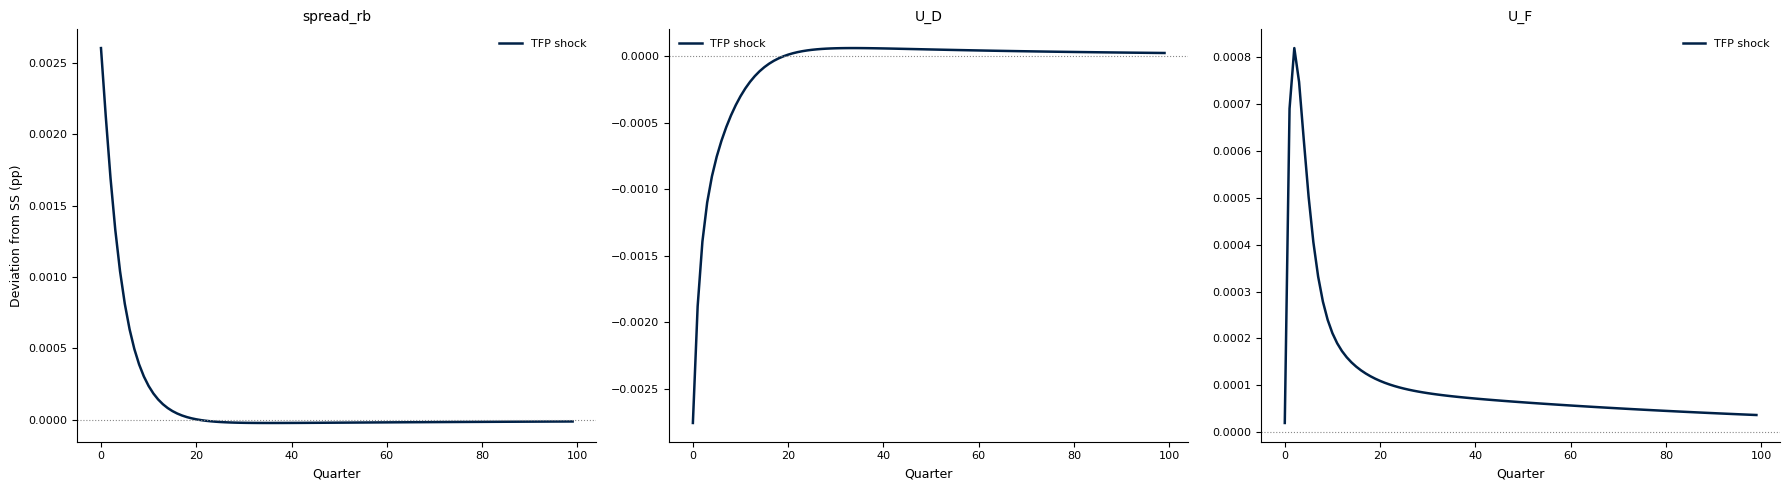

In [26]:
# Overview: output, consumption, real wage, bank net worth, bond rate
show_irfs([irfs_def_D], ['spread_rb','U_D',"U_F"],['TFP shock', 'Default shock']) 

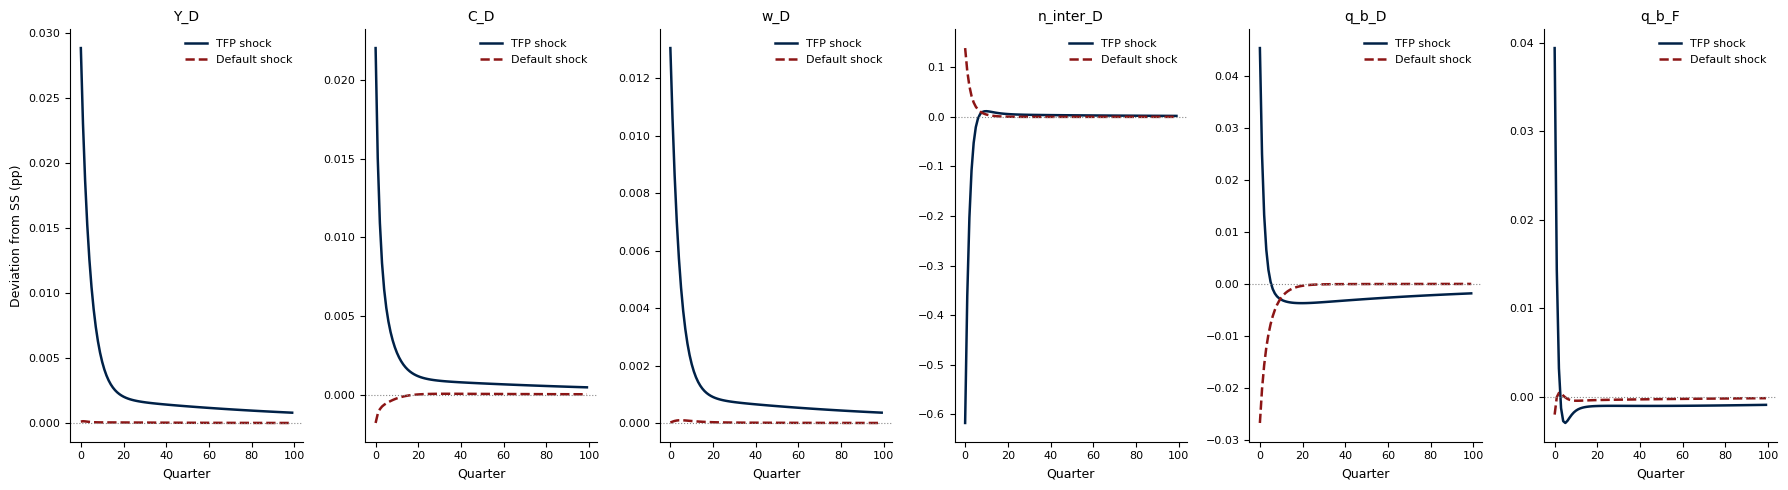

In [27]:
# Overview: output, consumption, real wage, bank net worth, bond rate
show_irfs([irfs_Z_D, irfs_def_D], 
          ['Y_D', 'C_D', 'w_D', 'n_inter_D', 'q_b_D', 'q_b_F'],
          ['TFP shock', 'Default shock']) 

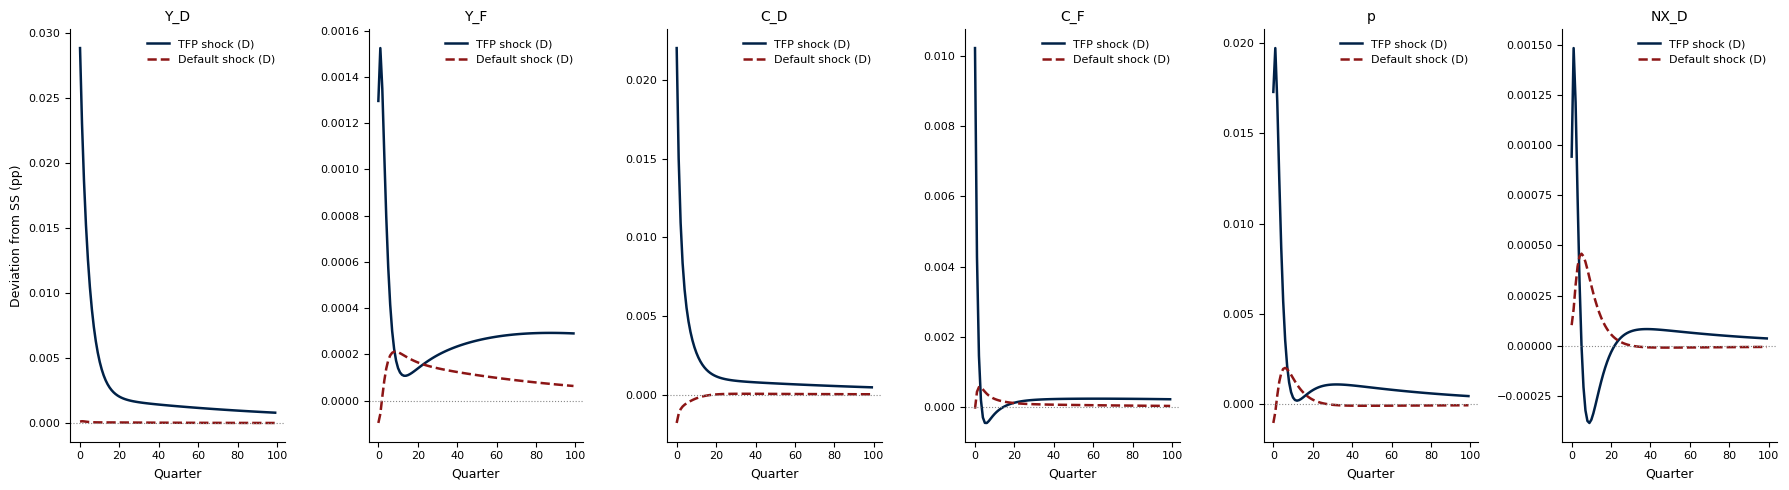

In [28]:
# ── 1. Output, Consumption & Trade ────────────────────────────────────────
# With flexible prices, inflation is zero; terms of trade p and NX adjust to
# clear goods markets across countries.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['Y_D', 'Y_F', 'C_D', 'C_F', 'p', 'NX_D'])

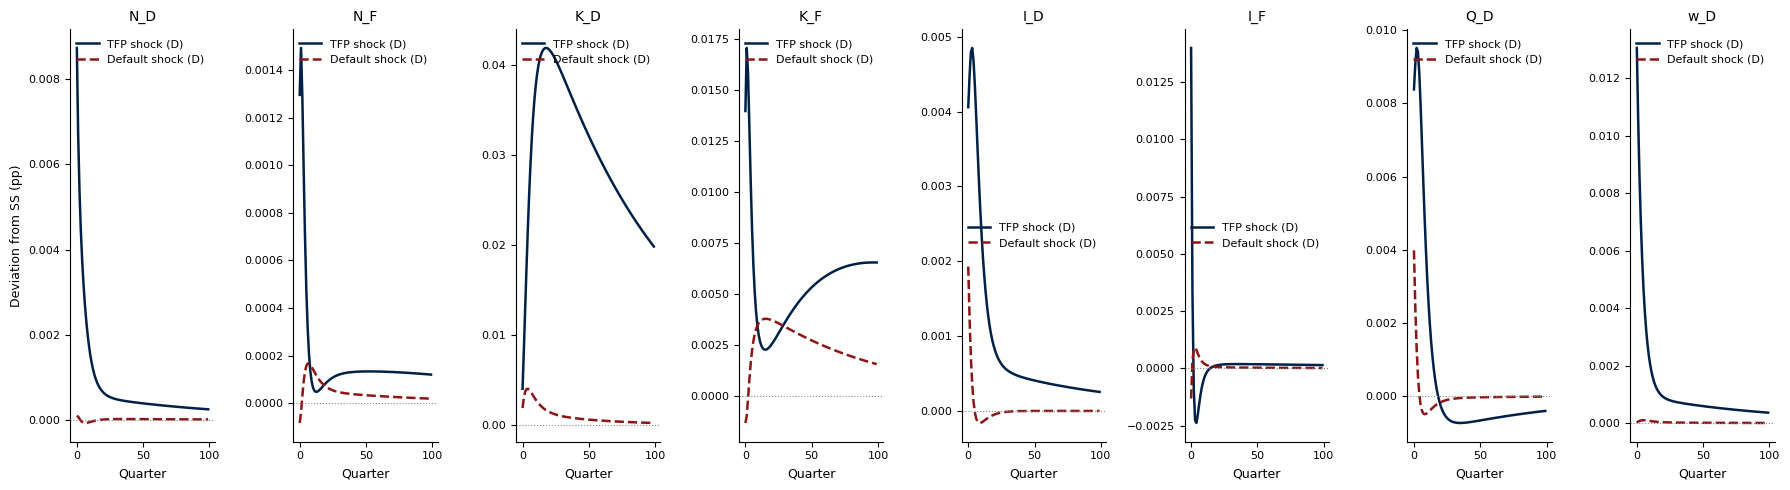

In [29]:
# ── 2. Labour, Capital & TFP ──────────────────────────────────────────────
# Suggestion: add Q (Tobin's q) and rk — these reveal whether output
# rigidity is coming from the investment or the labour margin.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['N_D', 'N_F', 'K_D', 'K_F', 'I_D', 'I_F', 'Q_D', 'w_D'])


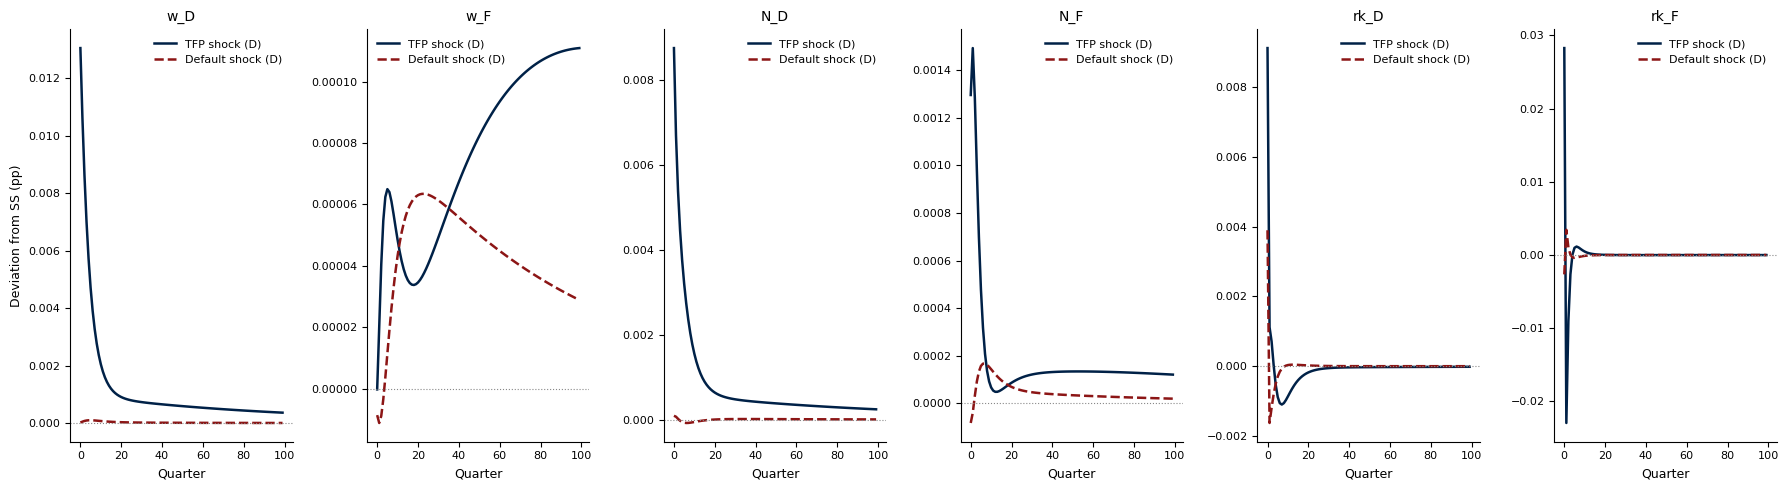

In [30]:
# ── 3. Factor Prices ──────────────────────────────────────────────────────────
# Under flexible prices mc = 1 always; the interesting margins are factor prices.
# rk = rental rate of capital; w = real wage. Both move with TFP and default shocks.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['w_D', 'w_F', 'N_D', 'N_F', 'rk_D', 'rk_F'])

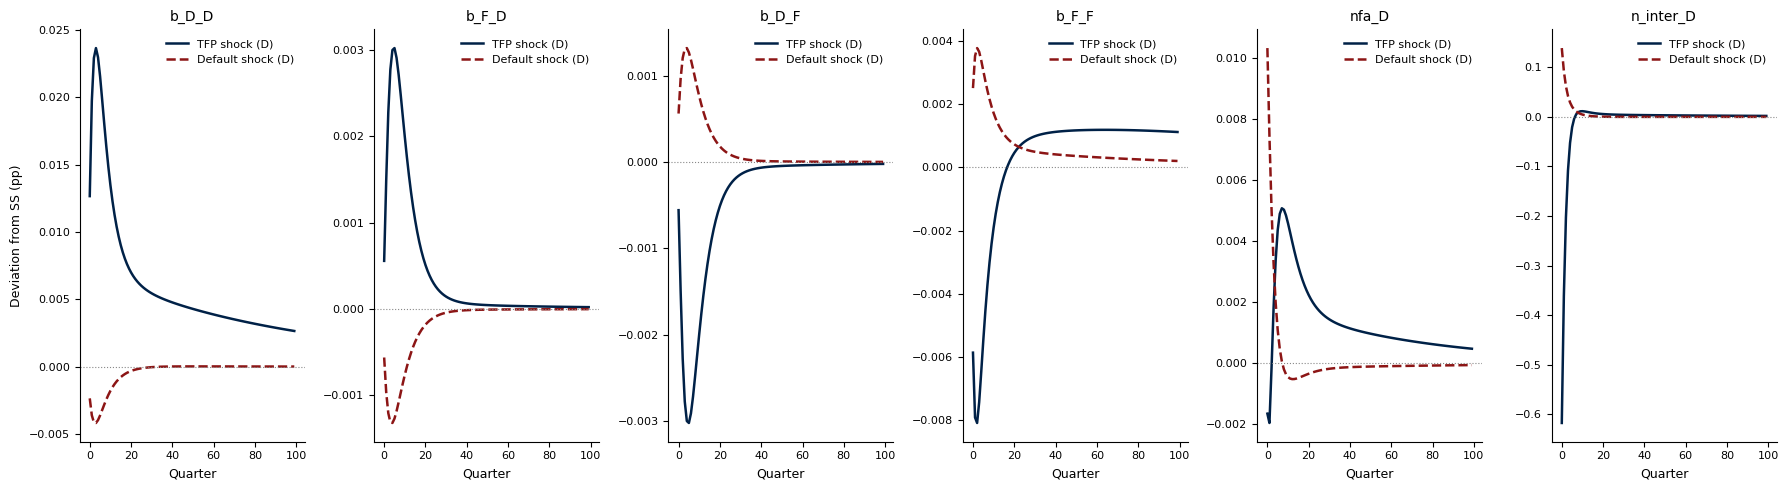

In [31]:
# ── 4. Bond Holdings & External Position ──────────────────────────────────────
# nfa_D = q_b_F·b_F_D − q_b_D·b_D_F: D's net foreign asset position (in D-goods).
# n_inter_D: D bank net worth — shows financial amplification of sovereign shocks.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_D_D', 'b_F_D', 'b_D_F', 'b_F_F', 'nfa_D', 'n_inter_D'])

In [ ]:
# ── 5. Rates & Returns ────────────────────────────────────────────────────────
# rdep_D/F are fixed exogenously at SS=0 to prevent the perverse deposit-rate
# margin channel. rk_D: return on physical capital. rn_D: bank portfolio return.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['rb_actual_D', 'rb_actual_F', 'rn_D', 'rn_F', 'rk_D'])

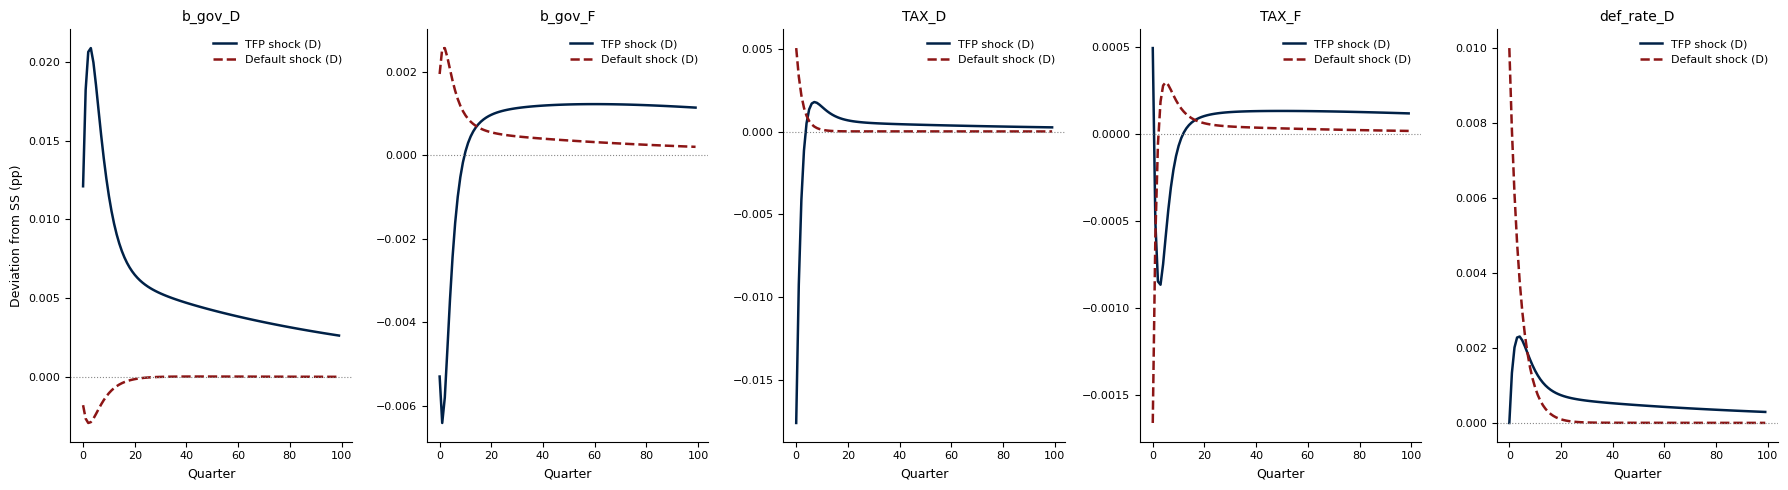

In [33]:
# ── 6. Fiscal ─────────────────────────────────────────────────────────────
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_gov_D', 'b_gov_F', 'TAX_D', 'TAX_F', 'def_rate_D'])


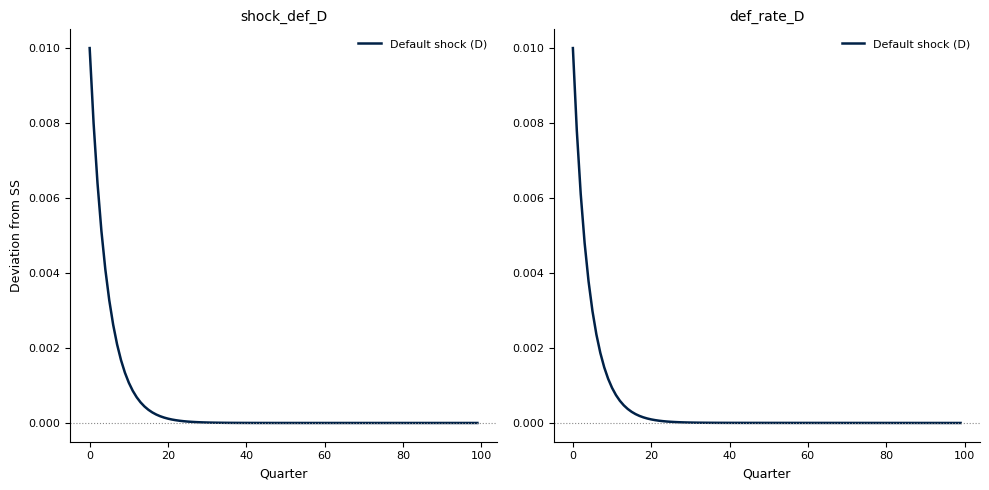

In [34]:
# Default shock decomposition: exogenous shock vs total default rate
irfs_def_D_plot = dict(irfs_def_D)
irfs_def_D_plot["shock_def_D"] = dShock_def_D

show_irfs([irfs_def_D_plot],
          variables=["shock_def_D", "def_rate_D"],
          labels=["Default shock (D)"],
          ylabel="Deviation from SS",
          figsize=(10, 5))


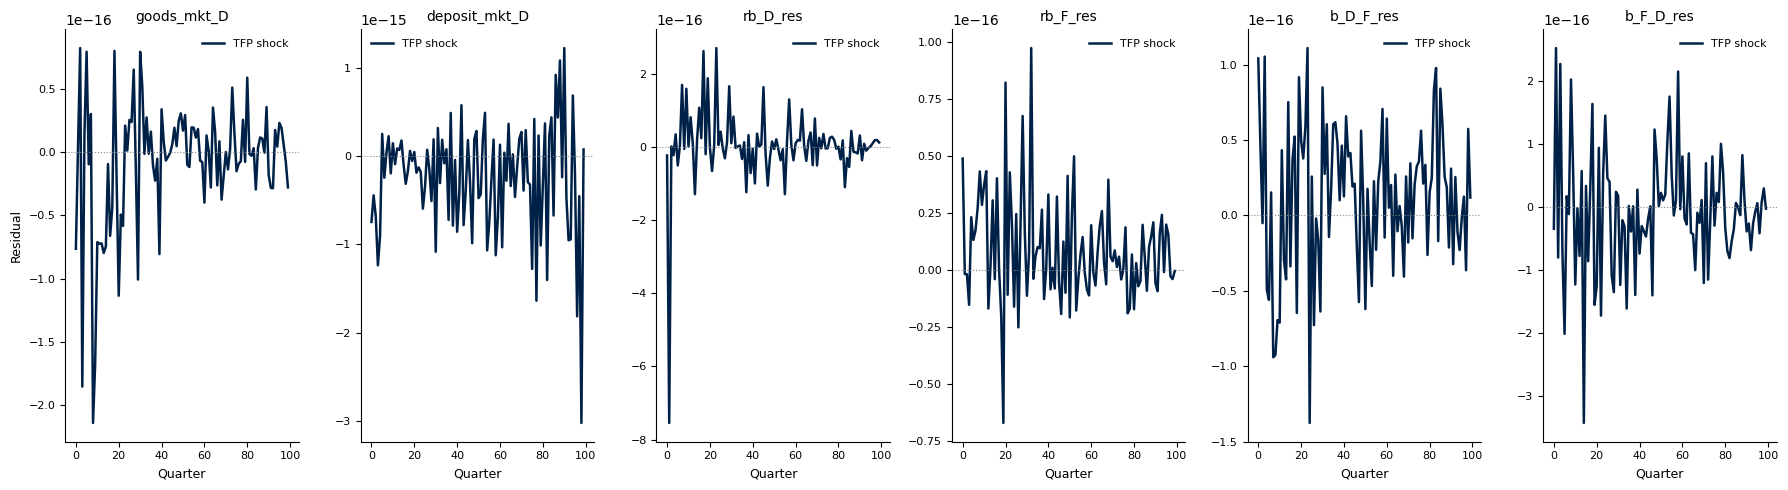

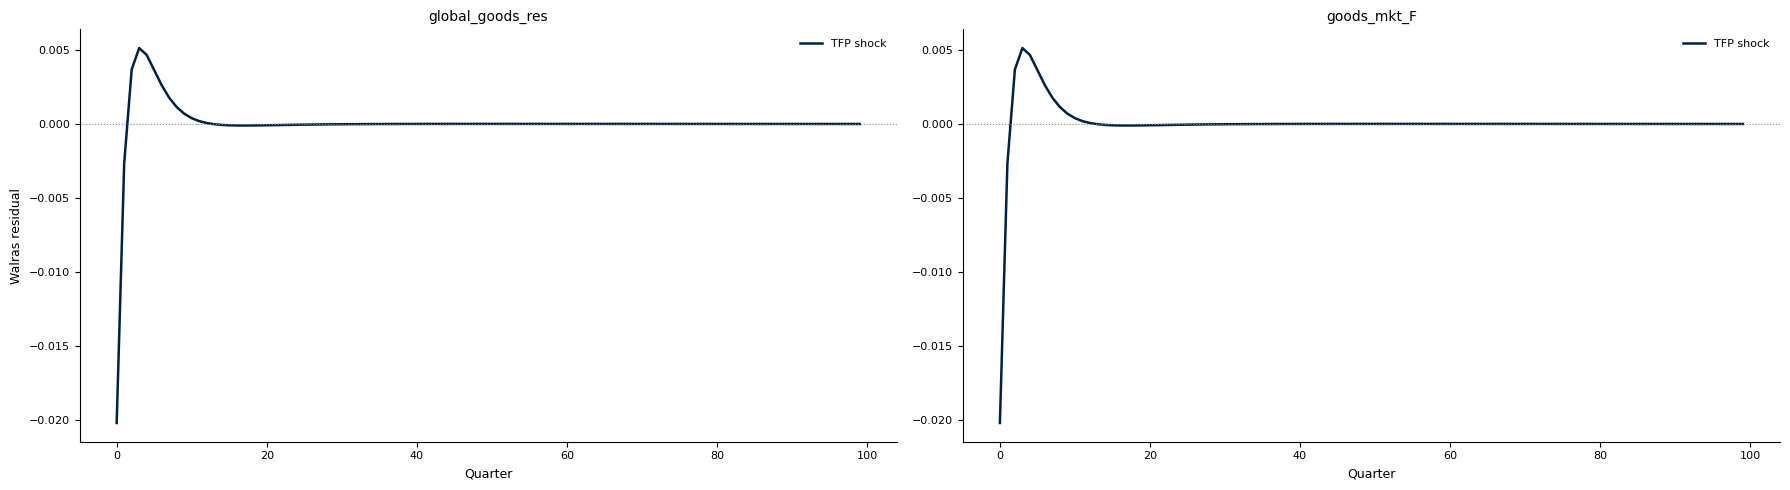

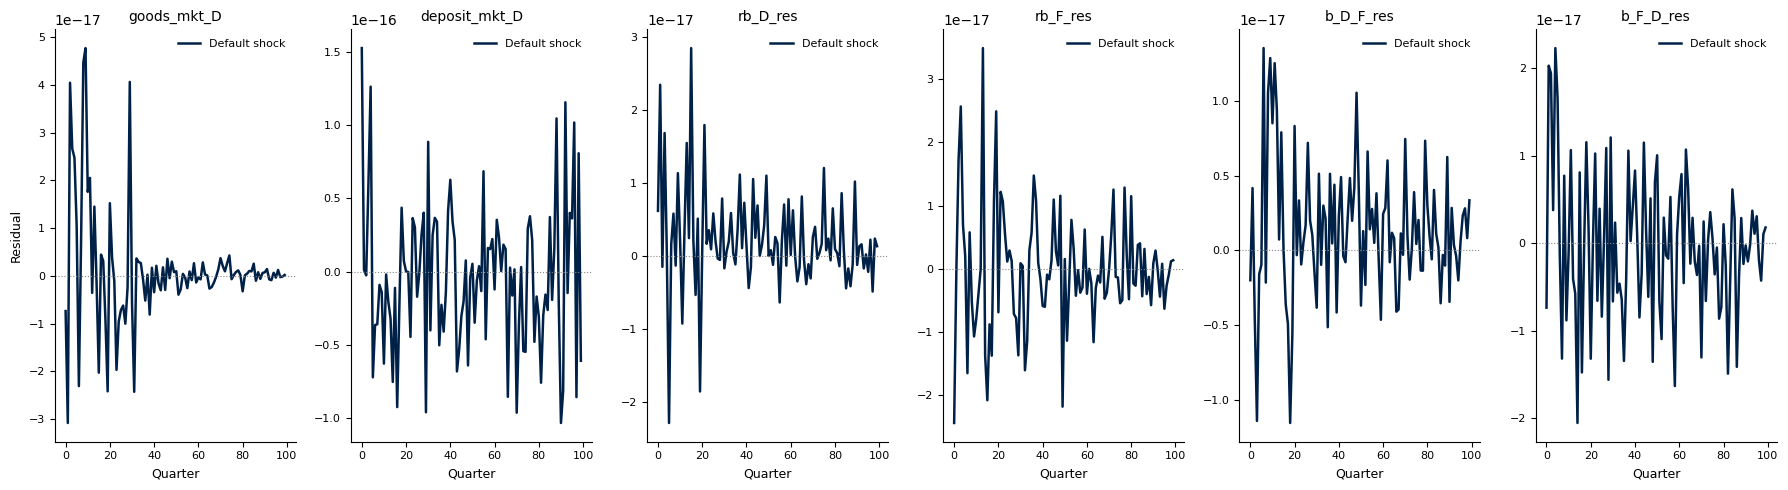

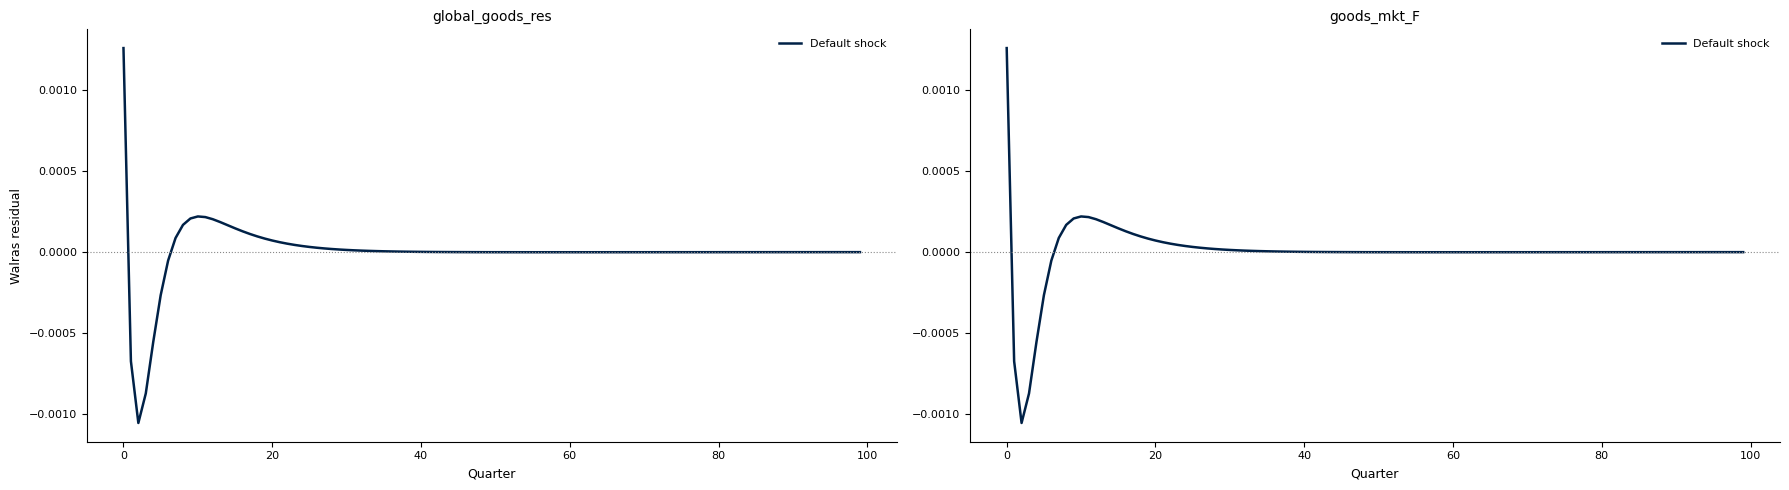

In [35]:
show_irfs([irfs_Z_D], labels=['TFP shock'], 
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_Z_D], labels=['TFP shock'],
          variables=['global_goods_res', 'goods_mkt_F'],
          ylabel='Walras residual')
show_irfs([irfs_def_D], labels=['Default shock'], 
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_def_D], labels=['Default shock'],
          variables=['global_goods_res', 'goods_mkt_F'],
          ylabel='Walras residual')  
